<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/modelo-Relu-Edgar/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!rm -fr images

In [5]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

In [6]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [7]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descargando imagenes...
Descargando anotaciones...
Descompactando imagenes...
Descompactando anotaciones...


In [8]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [9]:
#Hacemos que se revuelvean los datos
random.seed( 42 )
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [10]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [11]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [12]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for archivo in archivos:
        shutil.move( archivo, f'{destino}/{archivo.name}' )

In [13]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

In [14]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


In [15]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


**fin de codigo grupo**

# ****Intento con Batch Normalizaton y Dropout**

In [30]:
modelo_relu_bn_dropout = keras.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
], name="modelo_relu_bn_dropout")

In [31]:
modelo_relu_bn_dropout.summary()

Model: "modelo_relu_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [32]:
modelo_relu_bn_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
early_stopping_bn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [34]:
history_relu_bn_dropout = modelo_relu_bn_dropout.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=80,
    callbacks=[early_stopping_bn]
)

Epoch 1/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.6641 - loss: 0.6446 - val_accuracy: 0.6766 - val_loss: 0.6749
Epoch 2/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.6834 - loss: 0.5918 - val_accuracy: 0.6779 - val_loss: 0.7038
Epoch 3/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.6878 - loss: 0.5838 - val_accuracy: 0.6779 - val_loss: 0.8609
Epoch 4/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.6933 - loss: 0.5782 - val_accuracy: 0.6915 - val_loss: 0.6453
Epoch 5/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.6987 - loss: 0.5645 - val_accuracy: 0.6861 - val_loss: 0.5933
Epoch 6/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.7023 - loss: 0.5631 - val_accuracy: 0.6847 - val_loss: 0.6842
Epoch 7/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.7089 - loss: 0.5519 - val_accuracy: 0.6834 - val_loss: 0.6446
Epoch 8/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.7162 - loss: 0.5409 -

In [35]:
resultado_test_bn = modelo_relu_bn_dropout.evaluate(test_ds_eval)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.8349 - loss: 0.3523


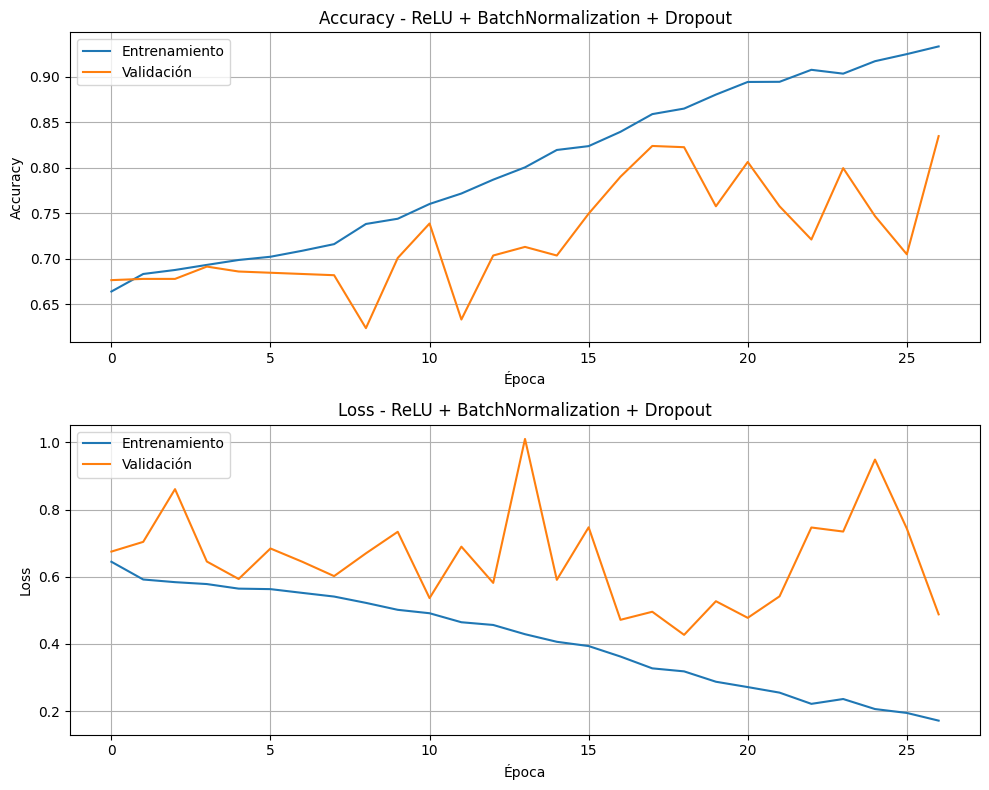

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Accuracy
plt.subplot(2, 1, 1)
plt.plot(history_relu_bn_dropout.history["accuracy"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_accuracy"], label="Validación")
plt.title("Accuracy - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(2, 1, 2)
plt.plot(history_relu_bn_dropout.history["loss"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_loss"], label="Validación")
plt.title("Loss - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ****Inicio Tercer Intento Data Argumentation**

In [16]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15)
], name="data_augmentation")

In [19]:
modelo_relu_augmentation = keras.Sequential([
    layers.Input(shape=(160,160,3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(2, activation="softmax")
], name="modelo_relu_augmentation")

In [20]:
modelo_relu_augmentation.summary()

Model: "modelo_relu_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 92416)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,914,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,934,210 (22.64 MB)

 Trainable params: 5,934,210 (22.64 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
modelo_relu_augmentation.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
early_stopping_augmentation = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [23]:
history_relu_augmentation = modelo_relu_augmentation.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=80,
    callbacks=[early_stopping_augmentation]
)

Epoch 1/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.6617 - loss: 38.7589 - val_accuracy: 0.6982 - val_loss: 0.5849
Epoch 2/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7003 - loss: 0.5704 - val_accuracy: 0.6847 - val_loss: 0.6068
Epoch 3/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.7111 - loss: 0.5645 - val_accuracy: 0.6861 - val_loss: 0.5794
Epoch 4/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.7062 - loss: 0.5589 - val_accuracy: 0.6942 - val_loss: 0.5700
Epoch 5/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7172 - loss: 0.5560 - val_accuracy: 0.7023 - val_loss: 0.5770
Epoch 6/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.7124 - loss: 0.5520 - val_accuracy: 0.7050 - val_loss: 0.5709
Epoch 7/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7287 - loss: 0.5388 - val_accuracy: 0.7077 - val_loss: 0.5725
Epoch 8/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.7265 - loss: 0.5373 -

In [ ]:
test_ds_eval = keras.utils.image_dataset_from_directory(
    carpeta_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 739 files belonging to 2 classes.


In [25]:
resultado_test_augmentation = modelo_relu_augmentation.evaluate(test_ds_eval)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7686 - loss: 0.4516


In [26]:
y_true = []
y_pred = []

for imagenes, etiquetas in test_ds_eval:
    predicciones = modelo_relu_augmentation.predict(imagenes, verbose=0)

    y_true.extend(etiquetas.numpy().flatten())
    y_pred.extend(tf.argmax(predicciones, axis=1).numpy())

In [27]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.7982
Recall: 0.8798


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[129 111]
 [ 60 439]]


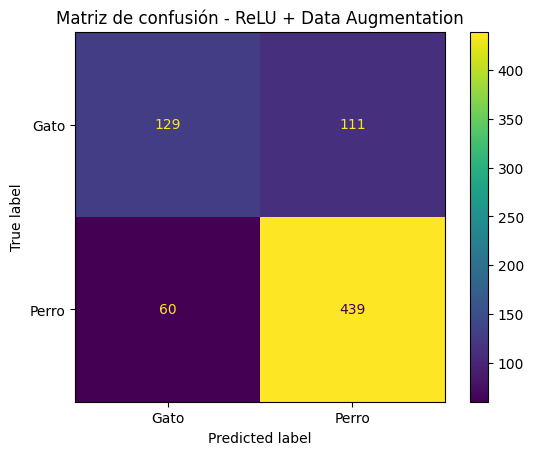

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Gato", "Perro"]
)

disp.plot()
plt.title("Matriz de confusión - ReLU + Data Augmentation")
plt.show()

**Fin Tercer Intento Data Argumentation**

# ****Inicio con Dropout**

In [26]:
#intentamos con Dropout****
modelo_relu_dropout = keras.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2, activation='softmax')
], name="modelo_relu_dropout")

In [25]:
modelo_relu_dropout.summary()

Model: "modelo_relu_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 92416)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     5,914,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,934,210 (22.64 MB)

 Trainable params: 5,934,210 (22.64 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
modelo_relu_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stopping_dropout = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [30]:
history_relu_dropout = modelo_relu_dropout.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=80,
    callbacks=[early_stopping_dropout]
)

Epoch 1/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.6604 - loss: 6.2692 - val_accuracy: 0.6806 - val_loss: 0.6051
Epoch 2/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.7170 - loss: 0.5606 - val_accuracy: 0.6752 - val_loss: 0.5978
Epoch 3/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.7717 - loss: 0.4752 - val_accuracy: 0.6631 - val_loss: 0.6501
Epoch 4/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.8163 - loss: 0.4041 - val_accuracy: 0.6712 - val_loss: 0.7376
Epoch 5/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.8623 - loss: 0.3151 - val_accuracy: 0.6631 - val_loss: 0.7952
Epoch 6/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8951 - loss: 0.2542 - val_accuracy: 0.6658 - val_loss: 0.9290
Epoch 7/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9131 - loss: 0.2151 - val_accuracy: 0.6928 - val_loss: 1.0236
Epoch 8/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.9296 - loss: 0.1861 - 

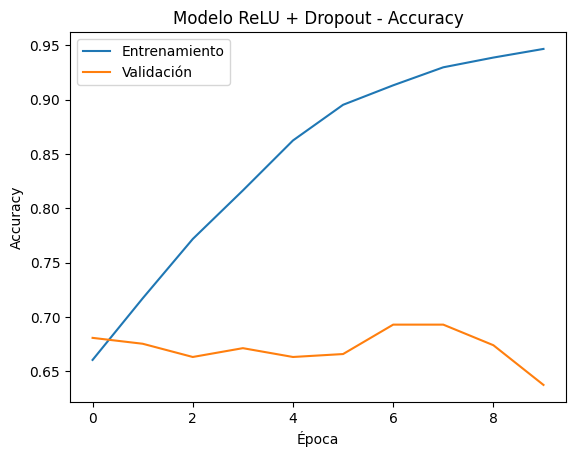

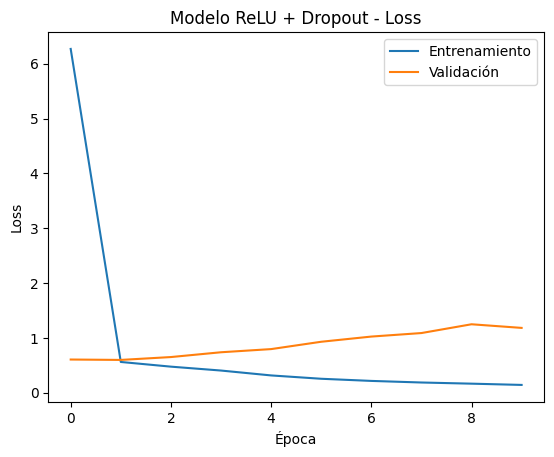

In [31]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_relu_dropout.history["accuracy"], label="Entrenamiento")
plt.plot(history_relu_dropout.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Modelo ReLU + Dropout - Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history_relu_dropout.history["loss"], label="Entrenamiento")
plt.plot(history_relu_dropout.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Modelo ReLU + Dropout - Loss")
plt.legend()
plt.show()

****Fin intento Dropout**

# ****OJO: Inicio de codigo con sobreentenamiento (no ejecutar por cambio con droput)**

In [32]:
#MODELO SIN DROPUT
modelo_relu_EV = keras.Sequential([
    layers.Input(shape=(160, 160, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
], name="modelo_relu_EV")

In [18]:
modelo_relu_EV.summary()

Model: "modelo_relu_EV"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 92416)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,914,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,934,210 (22.64 MB)

 Trainable params: 5,934,210 (22.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo_relu_EV.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "mejor_modelo_relu_EV.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
#Se guarfa historial con history para despues graficar
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_relu_EV = modelo_relu_EV.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=80,
    callbacks=[early_stopping]
)

Epoch 1/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.6876 - loss: 0.6031 - val_accuracy: 0.6901 - val_loss: 0.6010
Epoch 2/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7542 - loss: 0.4701 - val_accuracy: 0.6806 - val_loss: 0.6176
Epoch 3/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.8451 - loss: 0.3364 - val_accuracy: 0.6834 - val_loss: 0.7416
Epoch 4/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.9136 - loss: 0.2125 - val_accuracy: 0.6604 - val_loss: 0.9873
Epoch 5/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9518 - loss: 0.1324 - val_accuracy: 0.6996 - val_loss: 1.2834
Epoch 6/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.9733 - loss: 0.0875 - val_accuracy: 0.6942 - val_loss: 1.5816
Epoch 7/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.9778 - loss: 0.0910 - val_accuracy: 0.6888 - val_loss: 1.7550
Epoch 8/80
185/185 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9880 - loss: 0.0488 - val_accu

**Fin de codigo sin drout (con sobre entrenamiento)